In [4]:
pip install biopython

In [2]:
filename="/content/sequence.fasta"

In [6]:
from Bio import SeqIO

In [12]:
records = list(SeqIO.parse(filename, "fasta"))

if records:
    print(f"Number of records found: {len(records)}")
    print("\nFirst record details:")
    first_record = records[0]
    print(f"ID: {first_record.id}")
    print(f"Description: {first_record.description}")
    print(f"Sequence length: {len(first_record.seq)}")
    print(f"Sequence: {str(first_record.seq)[:75]}")
else:
    print("No records found in the FASTA file.")

Number of records found: 1

First record details:
ID: NG_047557.1
Description: NG_047557.1 Staphylococcus aureus N315 bleO gene for bleomycin binding protein, complete CDS
Sequence length: 605
Sequence: CGGGCCATTTTGCGTAATAAGAAAAAGGATTAATTATGAGCGAATTGAATTAATAATAAGGTAATAGATTTACAT


In [8]:
if records:
    nucleotide_counts = {"A": 0, "T": 0, "C": 0, "G": 0}
    sequence_str = str(first_record.seq).upper()

    for nucleotide in sequence_str:
        if nucleotide in nucleotide_counts:
            nucleotide_counts[nucleotide] += 1

    print("\nNucleotide counts:")
    for nuc, count in nucleotide_counts.items():
        print(f"{nuc}: {count}")
else:
    print("No records found to count nucleotides")


Nucleotide counts:
A: 181
T: 195
C: 88
G: 141


/tmp/ipykernel_6195/107798488.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Nucleotide', y='Count', data=df_nucleotide_counts, palette='viridis')


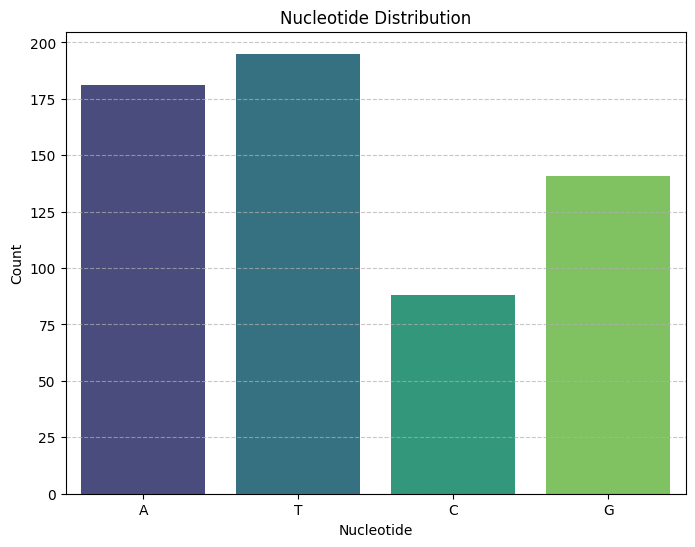

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'nucleotide_counts' in locals() and nucleotide_counts:
    # Convert the dictionary to a pandas DataFrame for easier plotting
    df_nucleotide_counts = pd.DataFrame(nucleotide_counts.items(), columns=['Nucleotide', 'Count'])

    fig = plt.figure(figsize=(8, 6))
    sns.barplot(x='Nucleotide', y='Count', data=df_nucleotide_counts, palette='viridis')
    plt.title('Nucleotide Distribution')
    plt.xlabel('Nucleotide')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Nucleotide counts not available or empty")

In [10]:
if 'df_nucleotide_counts' in locals():
    csv_filename = 'nucleotide_counts.csv'
    df_nucleotide_counts.to_csv(csv_filename, index=False)
    print(f"Nucleotide counts saved to {csv_filename}")
else:
    print("DataFrame 'df_nucleotide_counts' not found. Please ensure nucleotide counts have been generated.")

Nucleotide counts saved to nucleotide_counts.csv


In [13]:
if 'nucleotide_counts' in locals() and nucleotide_counts:
    g_count = nucleotide_counts.get('G', 0)
    c_count = nucleotide_counts.get('C', 0)
    a_count = nucleotide_counts.get('A', 0)
    t_count = nucleotide_counts.get('T', 0)

    total_nucleotides = g_count + c_count + a_count + t_count

    if total_nucleotides > 0:
        gc_content = ((g_count + c_count) / total_nucleotides) * 100
        print(f"GC-content: {gc_content:.2f}%")
    else:
        print("Cannot calculate GC-content")
else:
    print("Nucleotide counts not available")

GC-content: 37.85%
